In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve, auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv('smartcart_dataset_final.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nClass ratio: "
      f"{(df['label']==0).sum()}"
      f" normal vs "
      f"{(df['label']==1).sum()} attack")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (7099, 15)

Label distribution:
label
0    5517
1    1582
Name: count, dtype: int64

Class ratio: 5517 normal vs 1582 attack

First 5 rows:


,src_ip,relative_time,iat_mean,iat_std,jitter,pps,byte_rate,avg_pkt_size,flow_duration,syn_count,ack_count,protocol_type,sidp_entropy,dpdi_entropy,label
0,10.1.1.3,0.000000,0.165214,0.188139,0.219193,6.0,770.0,128.333333,0.826068,2,2,1,1.251629,1.251629,0
1,10.1.1.4,0.102937,0.176660,0.245890,0.390557,5.0,600.0,120.000000,0.706640,2,2,1,0.721928,0.721928,0
2,10.1.1.5,0.202027,0.048710,0.035548,0.071095,3.0,372.0,124.000000,0.097419,1,1,1,0.918296,0.918296,0
3,10.1.1.6,0.302018,0.048463,0.035391,0.070782,3.0,372.0,124.000000,0.096926,1,1,1,0.918296,0.918296,0
4,10.1.1.7,0.401946,0.048499,0.035337,0.070674,3.0,372.0,124.000000,0.096998,1,1,1,0.918296,0.918296,0


In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nFeature statistics:")
features = [
    'iat_mean','iat_std','jitter',
    'pps','byte_rate','avg_pkt_size',
    'flow_duration','syn_count','ack_count',
    'protocol_type',
    'sidp_entropy','dpdi_entropy'
]
print(df[features].describe().round(4))

Missing values:
src_ip           0
relative_time    0
iat_mean         0
iat_std          0
jitter           0
pps              0
byte_rate        0
avg_pkt_size     0
flow_duration    0
syn_count        0
ack_count        0
protocol_type    0
sidp_entropy     0
dpdi_entropy     0
label            0
dtype: int64

Feature statistics:
        iat_mean    iat_std     jitter        pps    byte_rate  avg_pkt_size  \
count  7099.0000  7099.0000  7099.0000  7099.0000    7099.0000     7099.0000   
mean      0.0785     0.0357     0.0434    77.6126   38260.8362      375.6613   
std       0.1140     0.0428     0.0696   143.8311   75553.3657      414.1558   
min       0.0001     0.0000     0.0000     2.0000     228.0000      114.0000   
25%       0.0179     0.0121     0.0087    10.0000    2078.0000      176.0000   
50%       0.0385     0.0236     0.0259    25.0000    4780.0000      186.0000   
75%       0.0749     0.0396     0.0419    53.0000   25505.0000      273.6864   
max       0.8986     0.38

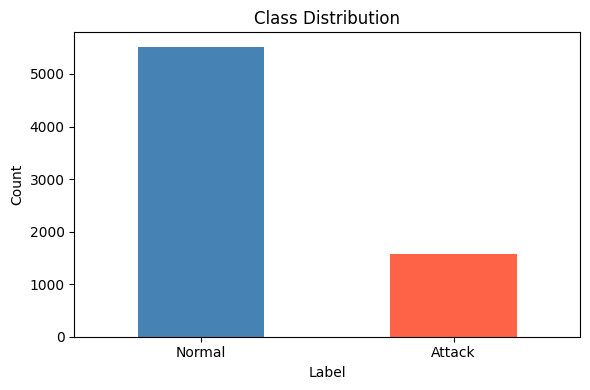

Saved: class_distribution.png


In [4]:
plt.figure(figsize=(6,4))
df['label'].value_counts().plot(
    kind='bar',
    color=['steelblue','tomato'])
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks([0,1],
           ['Normal','Attack'],
           rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Saved: class_distribution.png")

In [5]:
X = df[features]
y = df['label']

print(f"Features shape: {X.shape}")
print(f"Labels shape:   {y.shape}")
print(f"Feature names:  {features}")

Features shape: (7099, 12)
Labels shape:   (7099,)
Feature names:  ['iat_mean', 'iat_std', 'jitter', 'pps', 'byte_rate', 'avg_pkt_size', 'flow_duration', 'syn_count', 'ack_count', 'protocol_type', 'sidp_entropy', 'dpdi_entropy']


In [6]:
X_train, X_test, y_train, y_test = \
    train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y)

print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")
print(f"\nTrain label distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest label distribution:")
print(pd.Series(y_test).value_counts())

Train set: (5679, 12)
Test set:  (1420, 12)

Train label distribution:
label
0    4413
1    1266
Name: count, dtype: int64

Test label distribution:
label
0    1104
1     316
Name: count, dtype: int64


In [7]:
print("Training Random Forest...")

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)

model.fit(X_train, y_train)
print("Training complete")
print(f"Number of trees: {len(model.estimators_)}")

Training Random Forest...
Training complete
Number of trees: 100


In [8]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("="*45)
print("MODEL PERFORMANCE")
print("="*45)
print(f"Accuracy:  {accuracy:.4f}  "
      f"({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nDetailed Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['Normal','Attack']))

MODEL PERFORMANCE
Accuracy:  0.9746  (97.46%)
Precision: 0.9217
Recall:    0.9684
F1 Score:  0.9444

Detailed Report:
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98      1104
      Attack       0.92      0.97      0.94       316

    accuracy                           0.97      1420
   macro avg       0.96      0.97      0.96      1420
weighted avg       0.98      0.97      0.97      1420



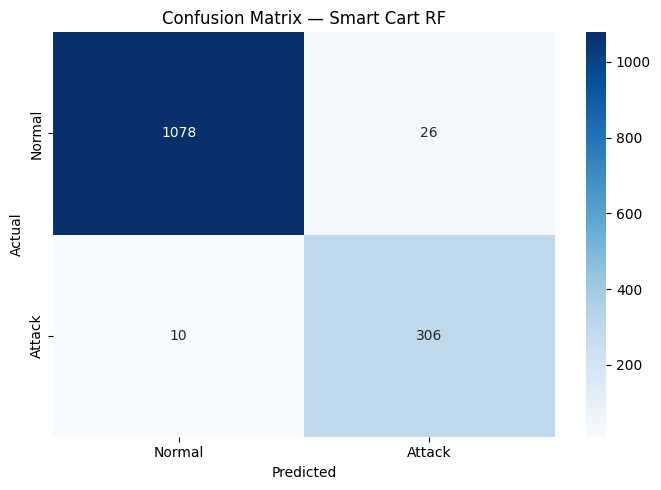

True Negatives:  1078
False Positives: 26
False Negatives: 10
True Positives:  306

False Positive Rate: 0.0236
False Negative Rate: 0.0316


In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal','Attack'],
    yticklabels=['Normal','Attack'])
plt.title('Confusion Matrix — Smart Cart RF')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"\nFalse Positive Rate: "
      f"{fp/(fp+tn):.4f}")
print(f"False Negative Rate: "
      f"{fn/(fn+tp):.4f}")

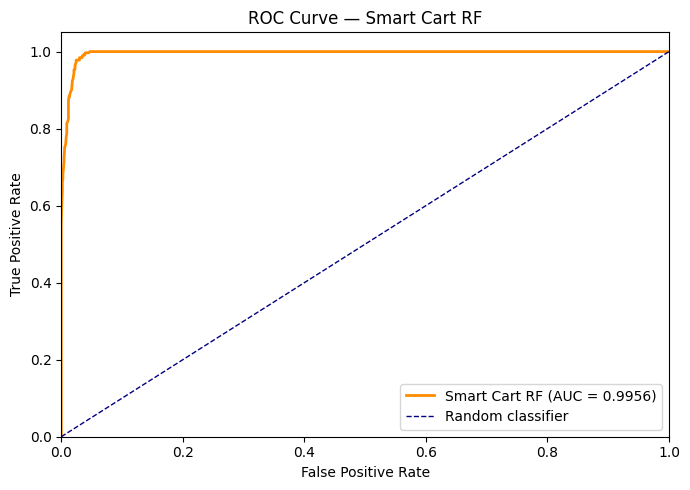

AUC Score: 0.9956


In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr,
    color='darkorange',
    lw=2,
    label=f'Smart Cart RF '
          f'(AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1],
    color='navy',
    lw=1,
    linestyle='--',
    label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Smart Cart RF')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

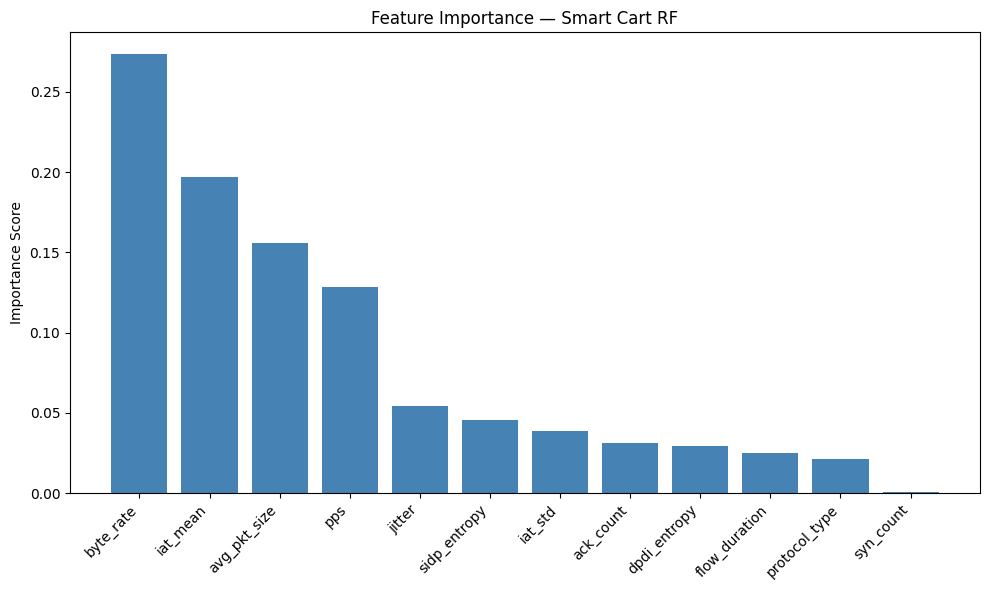


Feature Importance Ranking:
 1. byte_rate            0.2734
 2. iat_mean             0.1972
 3. avg_pkt_size         0.1559
 4. pps                  0.1287
 5. jitter               0.0540
 6. sidp_entropy         0.0453
 7. iat_std              0.0387
 8. ack_count            0.0309
 9. dpdi_entropy         0.0291
10. flow_duration        0.0253
11. protocol_type        0.0210
12. syn_count            0.0006


In [11]:
importance = model.feature_importances_
idx = np.argsort(importance)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(features)),
        importance[idx],
        color='steelblue')
plt.xticks(range(len(features)),
           [features[i] for i in idx],
           rotation=45,
           ha='right')
plt.title('Feature Importance — Smart Cart RF')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nFeature Importance Ranking:")
for rank, i in enumerate(idx):
    print(f"{rank+1:2d}. {features[i]:20s} "
          f"{importance[i]:.4f}")

In [12]:
pickle.dump(model,
    open('smartcart_rf_model.pkl', 'wb'))
print("Model saved: smartcart_rf_model.pkl")

print("\nAll files saved:")
print("  smartcart_rf_model.pkl")
print("  confusion_matrix.png")
print("  roc_curve.png")
print("  feature_importance.png")
print("  class_distribution.png")

Model saved: smartcart_rf_model.pkl

All files saved:
  smartcart_rf_model.pkl
  confusion_matrix.png
  roc_curve.png
  feature_importance.png
  class_distribution.png


In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=10,
                     shuffle=True,
                     random_state=42)

scores = cross_val_score(
    model, X, y,
    cv=cv,
    scoring='f1',
    n_jobs=-1)

print("10-Fold Cross Validation F1 Scores:")
for i, s in enumerate(scores):
    print(f"  Fold {i+1:2d}: {s:.4f}")
print(f"\nMean F1:  {scores.mean():.4f}")
print(f"Std F1:   {scores.std():.4f}")
print(f"Min F1:   {scores.min():.4f}")
print(f"Max F1:   {scores.max():.4f}")

10-Fold Cross Validation F1 Scores:
  Fold  1: 0.9536
  Fold  2: 0.9500
  Fold  3: 0.9394
  Fold  4: 0.9337
  Fold  5: 0.9474
  Fold  6: 0.9337
  Fold  7: 0.9527
  Fold  8: 0.9503
  Fold  9: 0.9451
  Fold 10: 0.9397

Mean F1:  0.9446
Std F1:   0.0071
Min F1:   0.9337
Max F1:   0.9536
